# Explainable AI for cyclic temporal data

We build a small, interpretable temporal classification example. The data contain only one binary variable, `active`, whose probability follows a repeating cycle. We then ask a transparent model to explain why the variable is predicted as active or inactive at particular times.

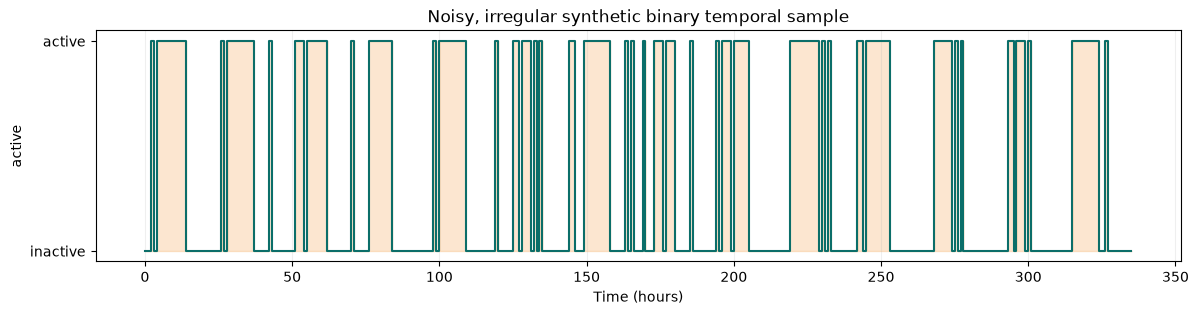

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

rng = np.random.default_rng(7)
n_samples = 24 * 14
hours = np.arange(n_samples)
period = 24
phase = 2 * np.pi * (hours % period) / period
cycle_number = hours // period

# Vary phase, amplitude, and threshold slightly from day to day.
phase_shift = rng.normal(0, 0.16, size=cycle_number.max() + 1)
amplitude = rng.normal(1.0, 0.10, size=cycle_number.max() + 1)
threshold = rng.normal(0.25, 0.08, size=cycle_number.max() + 1)

activity_score = (
    amplitude[cycle_number]
    * np.sin(phase - 0.45 + phase_shift[cycle_number])
    + 0.22 * rng.normal(size=n_samples)
)

active = (
    activity_score > threshold[cycle_number]
).astype(int)

# Occasionally miss an activation or create an unexpected activation.
missed_activations = (active == 1) & (rng.random(n_samples) < 0.08)
unexpected_activations = (active == 0) & (rng.random(n_samples) < 0.04)
active[missed_activations] = 0
active[unexpected_activations] = 1

fig, ax = plt.subplots(figsize=(14, 3))
ax.step(hours, active, where='post', color='#0b6e69', linewidth=1.5)
ax.fill_between(hours, active, step='post', alpha=0.22, color='#f28e2b')
ax.set(
    title='Noisy, irregular synthetic binary temporal sample',
    xlabel='Time (hours)',
    ylabel='active'
)
ax.set_yticks([0, 1], labels=['inactive', 'active'])
ax.grid(axis='x', alpha=0.2)
plt.show()

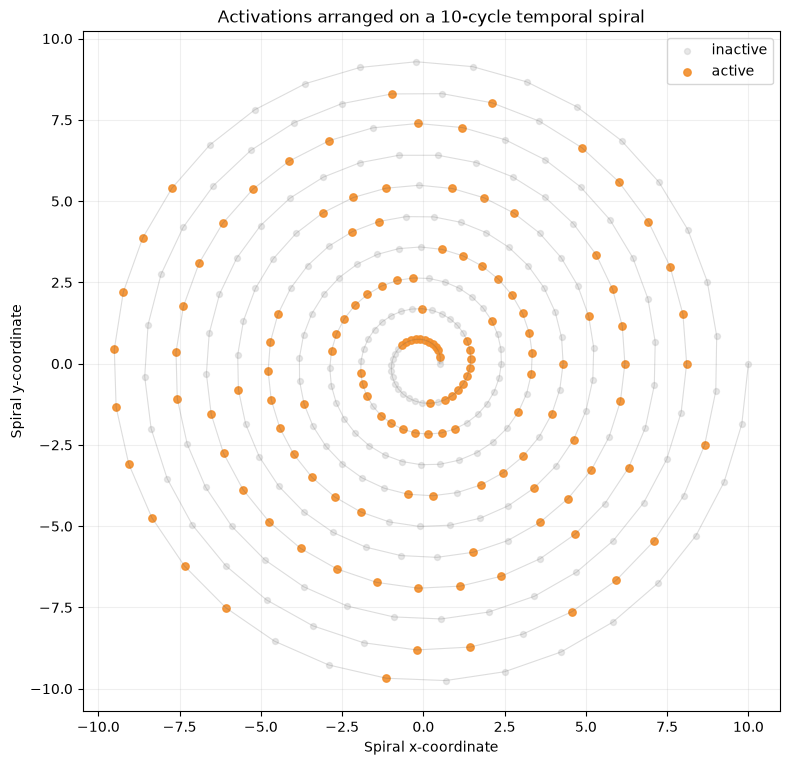

In [2]:
# Arrange the temporal sample along an outward spiral with 10 complete cycles.
n_points = len(active)
theta = np.linspace(0, 10 * 2 * np.pi, n_points)
radius = np.linspace(0.5, 10, n_points)

x_spiral = radius * np.cos(theta)
y_spiral = radius * np.sin(theta)

fig, ax = plt.subplots(figsize=(9, 9))

inactive = active == 0
ax.scatter(
    x_spiral[inactive],
    y_spiral[inactive],
    s=18,
    color='#bdbdbd',
    alpha=0.35,
    label='inactive'
)
ax.scatter(
    x_spiral[active == 1],
    y_spiral[active == 1],
    s=28,
    color='#f28e2b',
    alpha=0.9,
    label='active'
)

ax.plot(x_spiral, y_spiral, color='#555555', alpha=0.2, linewidth=0.8)
ax.set(
    title='Activations arranged on a 10-cycle temporal spiral',
    xlabel='Spiral x-coordinate',
    ylabel='Spiral y-coordinate'
)
ax.set_aspect('equal')
ax.legend()
ax.grid(alpha=0.2)
plt.show()

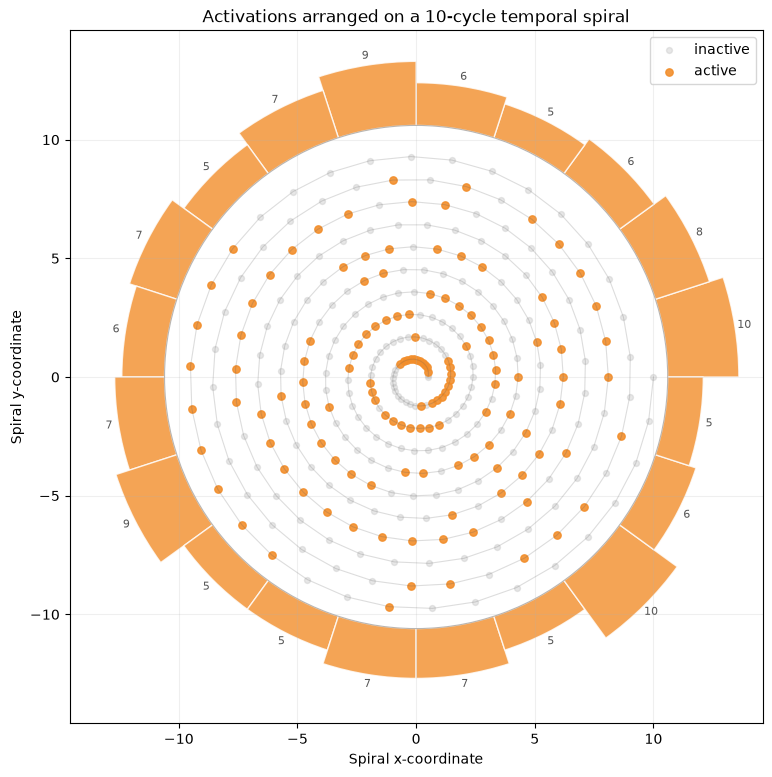

In [3]:
from matplotlib.patches import Wedge

# Arrange the temporal sample along an outward spiral with 10 complete cycles.
n_points = len(active)
theta = np.linspace(0, 10 * 2 * np.pi, n_points)
radius = np.linspace(0.5, 10, n_points)

x_spiral = radius * np.cos(theta)
y_spiral = radius * np.sin(theta)

fig, ax = plt.subplots(figsize=(9, 9))

inactive = active == 0
ax.scatter(
    x_spiral[inactive],
    y_spiral[inactive],
    s=18,
    color='#bdbdbd',
    alpha=0.35,
    label='inactive'
)
ax.scatter(
    x_spiral[active == 1],
    y_spiral[active == 1],
    s=28,
    color='#f28e2b',
    alpha=0.9,
    label='active'
)

ax.plot(x_spiral, y_spiral, color='#555555', alpha=0.2, linewidth=0.8)

# Outer histogram: count active samples in 20 angular (temporal) bins of the cycle.
bin_edges = np.linspace(0, 2 * np.pi, 21)
spiral_phase = np.mod(theta, 2 * np.pi)
bin_counts, _ = np.histogram(spiral_phase[active == 1], bins=bin_edges)

hist_base = radius.max() + 0.6
hist_max_height = 3.0
bar_heights = hist_max_height * bin_counts / bin_counts.max()

for start, end, height, count in zip(bin_edges[:-1], bin_edges[1:], bar_heights, bin_counts):
    ax.add_patch(Wedge(
        (0, 0),
        hist_base + height,
        np.degrees(start),
        np.degrees(end),
        width=height,
        facecolor='#f28e2b',
        edgecolor='white',
        alpha=0.8
    ))
    mid = (start + end) / 2
    label_radius = hist_base + height + 0.4
    ax.text(label_radius * np.cos(mid), label_radius * np.sin(mid), str(count),
            ha='center', va='center', fontsize=8, color='#555555')

ax.add_patch(plt.Circle((0, 0), hist_base, fill=False, color='#555555', alpha=0.4, linewidth=0.8))
plot_limit = hist_base + hist_max_height + 1.0
ax.set_xlim(-plot_limit, plot_limit)
ax.set_ylim(-plot_limit, plot_limit)

ax.set(
    title='Activations arranged on a 10-cycle temporal spiral',
    xlabel='Spiral x-coordinate',
    ylabel='Spiral y-coordinate'
)
ax.set_aspect('equal')
ax.legend()
ax.grid(alpha=0.2)
plt.show()


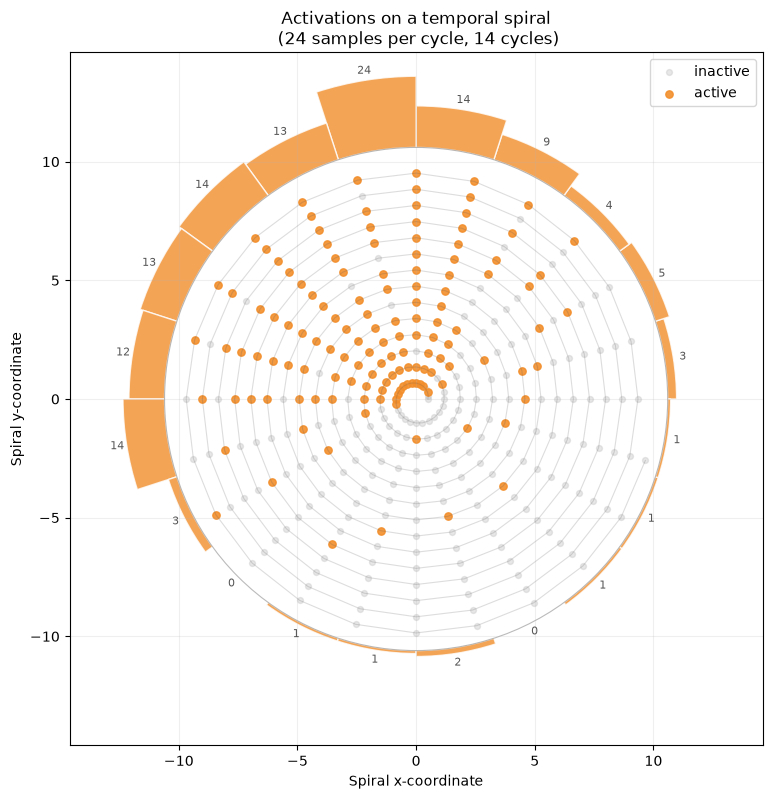

In [4]:
from spirals import plot_temporal_spiral


plot_temporal_spiral(active, n_bins=20, samples_per_cycle=24)
plt.show()

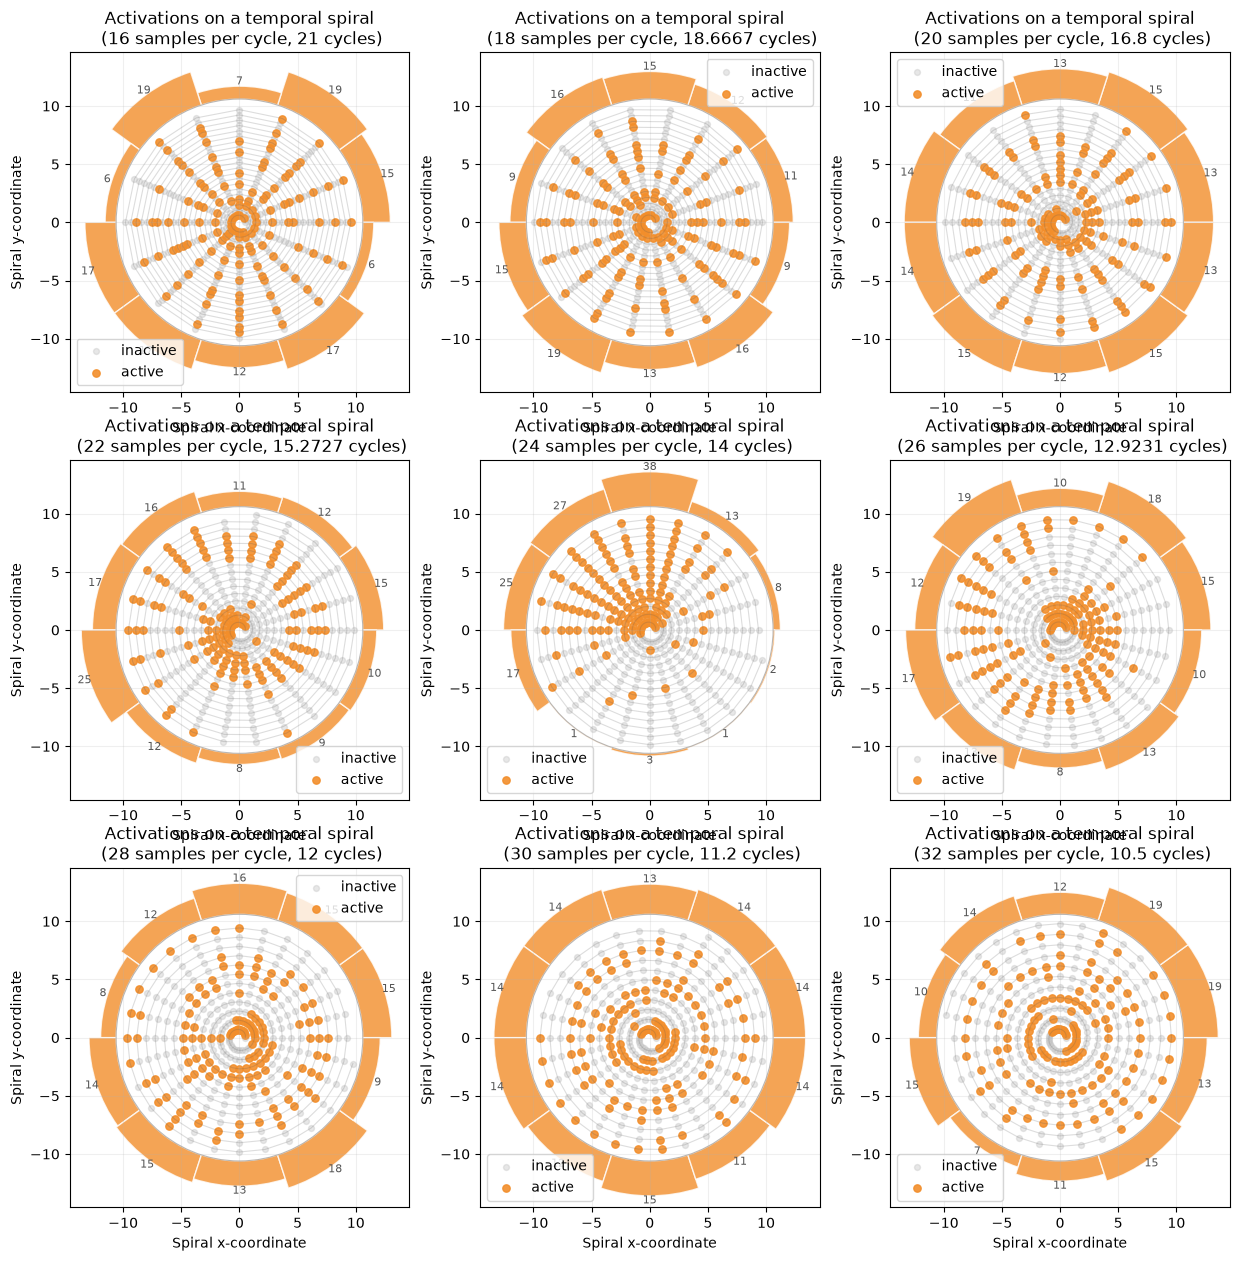

In [5]:
fig, ax_list = plt.subplots(3, 3, figsize=(15, 15))

ax_list = ax_list.flatten()

samples_per_cycle_list = [16, 18, 20, 22, 24, 26, 28, 30, 32]
for i, ax in enumerate(ax_list):
    plot_temporal_spiral(active, n_bins=10, samples_per_cycle=samples_per_cycle_list[i], ax=ax)

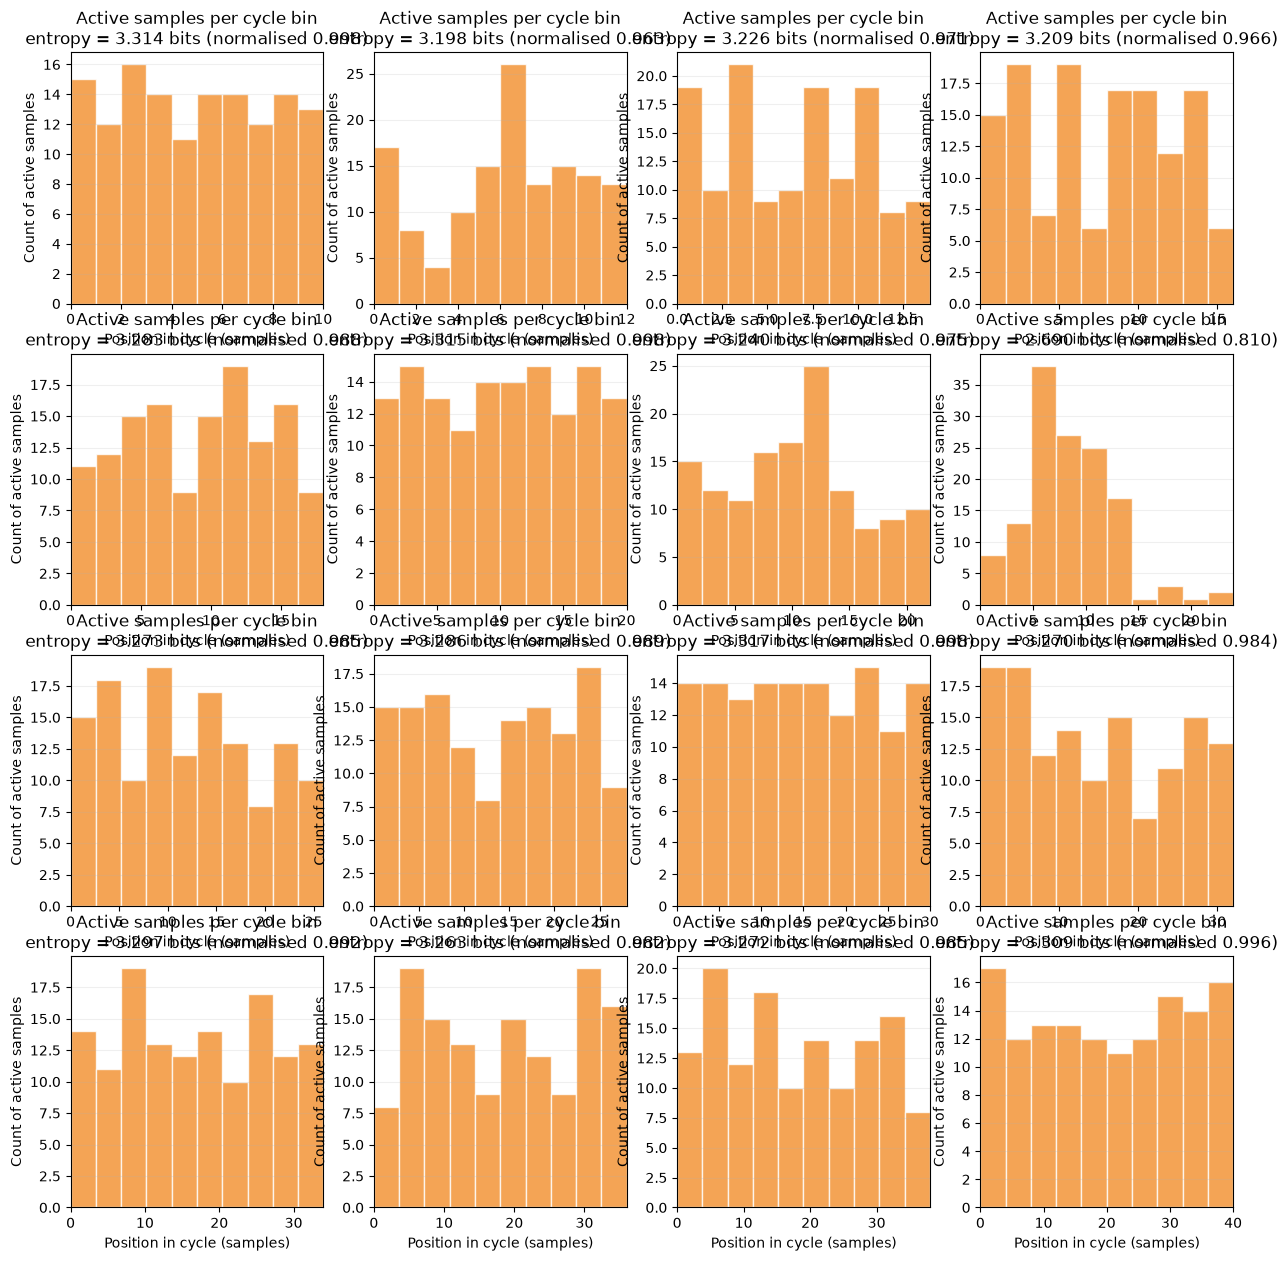

In [10]:
from spirals import plot_cycle_histogram

fig, ax_list = plt.subplots(4, 4, figsize=(15, 15))

samples_per_cycle_list = np.arange(10, 42, 2)

for i, ax in enumerate(ax_list.flatten()):
    plot_cycle_histogram(active, n_bins=10, samples_per_cycle=samples_per_cycle_list[i], ax=ax)

(<Figure size 900x350 with 1 Axes>,
 <Axes: title={'center': 'Histogram entropy by cycle length (10 bins)'}, xlabel='Samples per cycle', ylabel='Normalised entropy'>,
 array([0.99753827, 0.97934971, 0.96269706, 0.96386208, 0.97098588,
        0.98200966, 0.96595912, 0.9735458 , 0.988304  , 0.98260915,
        0.99800061, 0.99630504, 0.9752079 , 0.96232473, 0.80971053,
        0.92707749, 0.98524009, 0.98098174, 0.98903699, 0.99284667,
        0.99846057, 0.99078871, 0.98423294, 0.98672549, 0.9923802 ,
        0.99000733, 0.98237956, 0.99199197, 0.98493252, 0.99614639,
        0.99597018, 0.99666249, 0.99441514, 0.98252277, 0.97597844,
        0.99441514, 0.97074556, 0.87932441, 0.8096456 , 0.8675322 ,
        0.94772961, 0.9790418 , 0.98855162, 0.98406671, 0.9793183 ,
        0.98775998, 0.99561584, 0.9930639 , 0.99469355, 0.99389904]))

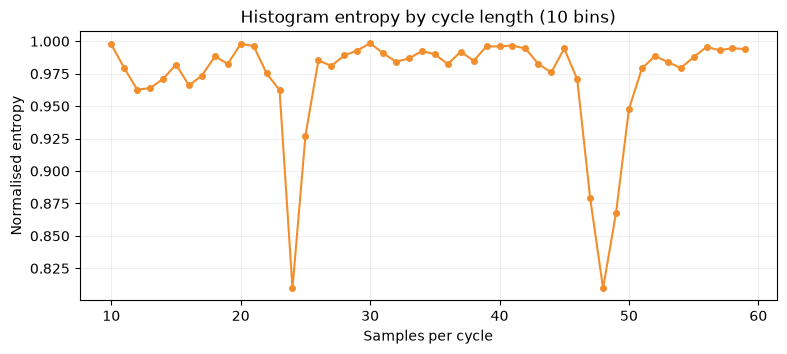

In [9]:
from spirals import plot_entropy_by_cycle_length

samples_per_cycle_list = np.arange(10, 60, 1)
plot_entropy_by_cycle_length(active, n_bins=10, samples_per_cycle_list=samples_per_cycle_list)